# Bodrum Hotel & Destination Intelligence
## 15 - Google Travel Customer Voice Intelligence Summary

Bu notebook yeni scraping/cleaning/agir NLP modeli kurmaz; 12+13+14 sonuclarini birlestirir.

In [1]:

import sys
sys.path.insert(0, r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews\src")
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

from bodrum_intelligence.reviews.common import master_hotel_csv_path

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\google_travel_customer_voice_summary"
os.makedirs(FIG_DIR, exist_ok=True)

clean = pd.read_csv(REPO_ROOT + r"\data\processed\google_travel_all_hotels_reviews_clean.csv")
rating_summary = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_rating_summary.csv")
profile_summary = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_profile_summary.csv")
area_summary = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_area_summary.csv")
hotel_aspect = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_hotel_aspect_mentions.csv")
aspect_rating = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_aspect_rating_summary.csv")
voice_profiles = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_customer_voice_profiles.csv")
sensitivity = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_google_only_sensitivity.csv")
master = pd.read_csv(master_hotel_csv_path())
print("master hotels:", len(master), "| hotels with >=1 google travel review:", clean['hotel_id'].nunique())


master hotels: 192 | hotels with >=1 google travel review: 104


## E2-E3: Dataset overview & coverage

In [2]:

hotels_with_reviews = set(clean["hotel_id"].unique())
no_review_hotels = master[~master["hotel_id"].isin(hotels_with_reviews)]
coverage = {
    "master_hotel_count": len(master),
    "hotels_with_google_travel_reviews": len(hotels_with_reviews),
    "hotels_with_no_google_travel_reviews": len(no_review_hotels),
    "coverage_pct": round(len(hotels_with_reviews) / len(master) * 100, 1),
    "review_count": len(clean),
    "area_count": clean["area"].nunique(),
    "rating_coverage_pct": round(clean["review_rating_numeric"].notna().mean() * 100, 1),
    "details_coverage_pct": round(clean["rooms_score"].notna().mean() * 100, 1),
}
for k, v in coverage.items():
    print(f"{k}: {v}")


master_hotel_count: 192
hotels_with_google_travel_reviews: 104
hotels_with_no_google_travel_reviews: 88
coverage_pct: 54.2
review_count: 2336
area_count: 14
rating_coverage_pct: 99.9
details_coverage_pct: 64.8


## E4: Rating intelligence

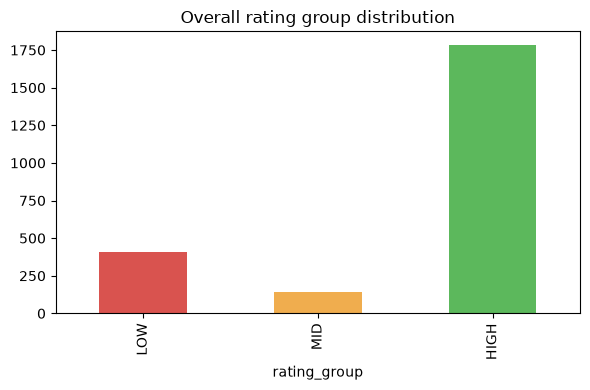

In [3]:

fig, ax = plt.subplots(figsize=(6,4))
clean["rating_group"].value_counts().reindex(["LOW","MID","HIGH"]).plot(kind="bar", ax=ax,
    color=["#d9534f","#f0ad4e","#5cb85c"])
ax.set_title("Overall rating group distribution")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\overall_rating_distribution.png", dpi=110)
plt.show()


## E5: Customer voice themes (overall)

In [4]:

top_overall = aspect_rating.sort_values("n_mentions", ascending=False).head(10)
top_positive = aspect_rating.sort_values("high_rating_share_when_mentioned", ascending=False).head(5)
top_negative = aspect_rating.sort_values("low_rating_share_when_mentioned", ascending=False).head(5)
print("TOP OVERALL ASPECTS:\n", top_overall[["aspect","n_mentions"]].to_string(index=False))
print("\nTOP POSITIVE-CONTEXT ASPECTS:\n", top_positive[["aspect","high_rating_share_when_mentioned"]].to_string(index=False))
print("\nTOP NEGATIVE-CONTEXT ASPECTS:\n", top_negative[["aspect","low_rating_share_when_mentioned"]].to_string(index=False))


TOP OVERALL ASPECTS:
      aspect  n_mentions
       FOOD        1377
      STAFF        1376
       ROOM        1328
CLEANLINESS        1174
  BEACH_SEA        1060
   LOCATION         815
 BAR_DRINKS         758
    SERVICE         700
PRICE_VALUE         690
      NOISE         594

TOP POSITIVE-CONTEXT ASPECTS:
                  aspect  high_rating_share_when_mentioned
     TRANSPORT_TRANSFER                              81.0
ANIMATION_ENTERTAINMENT                              80.6
                  STAFF                              79.0
                   FOOD                              77.9
               LOCATION                              77.8

TOP NEGATIVE-CONTEXT ASPECTS:
           aspect  low_rating_share_when_mentioned
  REFUND_PAYMENT                             55.0
            WIFI                             50.0
AIR_CONDITIONING                             44.6
     RESERVATION                             43.9
   COMMUNICATION                             43.1


## E6-E7: Hotel & area profiles (sample-adequate)

In [5]:

adequate = profile_summary[profile_summary["n_reviews"] >= 5].sort_values("n_reviews", ascending=False)
print(f"{len(adequate)} / {len(profile_summary)} hotels have n>=5 reviews (sample-adequate)")
adequate.head(10)


104 / 104 hotels have n>=5 reviews (sample-adequate)


,hotel_id,hotel_name,area,n_reviews,mean_rating,median_rating,low_share,high_share,median_word_count,details_coverage_pct,google_source_share_pct,sample_support
75,BOD128,Lugga Boutique Hotel & Beach,Ortakent-Yahşi,87,4.781609,5.0,0.023,0.931,38.0,71.3,89.7,STRONGER
33,BOD057,Selvi Bodrum,Göltürkbükü,79,3.506329,4.0,0.228,0.506,38.5,36.2,92.5,STRONGER
35,BOD060,Club Shark Hotel,Gümbet,78,4.307692,5.0,0.141,0.846,38.5,65.4,93.6,STRONGER
11,BOD013,"Sentido Bellazure - Akyarlar, Bodrum / Turkey",Akyarlar,72,4.027778,5.0,0.181,0.750,46.5,52.8,91.7,STRONGER
29,BOD052,Flamm Bodrum,Göltürkbükü,69,4.463768,5.0,0.130,0.855,38.0,44.9,92.8,STRONGER
36,BOD061,Gümbet Anıl Beach,Gümbet,65,4.000000,5.0,0.154,0.708,39.0,69.2,95.4,STRONGER
25,BOD045,Salmakis Resort & Spa,Bodrum Merkez,64,3.859375,4.5,0.219,0.719,48.0,48.4,93.8,STRONGER
6,BOD007,Kefaluka Resort,Akyarlar,60,4.066667,5.0,0.183,0.733,79.0,90.0,98.3,STRONGER
20,BOD032,Paloma Family Club Bitez,Bitez,60,4.583333,5.0,0.033,0.917,44.0,60.0,91.7,STRONGER
41,BOD067,Sami Beach Hotel,Gümbet,59,3.813559,5.0,0.254,0.695,42.0,55.9,93.2,STRONGER


In [6]:

area_summary.sort_values("review_count", ascending=False).head(10)


,area,hotel_count_with_reviews,review_count,review_weighted_mean_rating,median_hotel_rating,median_low_share,median_high_share
0,Gümbet,11,367,3.967847,5.0,0.200,0.7000
1,Ortakent-Yahşi,15,320,4.309375,5.0,0.172,0.7590
2,Akyarlar,14,300,4.190000,5.0,0.157,0.8000
3,Göltürkbükü,8,266,4.139623,5.0,0.100,0.8660
4,Bitez,9,210,4.200957,5.0,0.200,0.8000
5,Torba,11,193,4.300518,5.0,0.100,0.8500
6,Güvercinlik,8,183,3.775956,5.0,0.198,0.7000
7,Gündoğan,8,120,4.433333,5.0,0.100,0.9000
8,Gümüşlük,6,104,3.846154,5.0,0.227,0.7345
9,Yalıkavak,4,96,4.442708,5.0,0.100,0.9000


## E8-E9: Strength / concern signals (hotel + area)

In [7]:

strengths = voice_profiles[voice_profiles["top_high_context_aspects"].notna() &
                            (voice_profiles["top_high_context_aspects"] != "")]
concerns = voice_profiles[voice_profiles["top_low_context_aspects"].notna() &
                           (voice_profiles["top_low_context_aspects"] != "")]
print(f"{len(strengths)} hotels have an identified strength-signal aspect.")
print(f"{len(concerns)} hotels have an identified concern-signal aspect.")
strengths[["hotel_id","hotel_name","top_high_context_aspects"]].head(8)


101 hotels have an identified strength-signal aspect.
75 hotels have an identified concern-signal aspect.


,hotel_id,hotel_name,top_high_context_aspects
0,BOD001,Aksoy Taş Ev,BEACH_SEA;ROOM;FOOD
1,BOD002,Armonia Holiday Village & Spa,ROOM;FOOD;BAR_DRINKS
2,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,BEACH_SEA;STAFF;ROOM
3,BOD004,Bendis Beach Hotel,ANIMATION_ENTERTAINMENT;REFUND_PAYMENT
4,BOD005,ByAkkan,FOOD;STAFF;ROOM
5,BOD006,Club Marma Hotel,BEACH_SEA;FOOD;STAFF
6,BOD007,Kefaluka Resort,STAFF;FOOD;ANIMATION_ENTERTAINMENT
7,BOD008,LA BREZZA SUITE &HOTEL,ROOM;STAFF;FOOD


## E10-E15: Aspect deep-dives (PRICE_VALUE, CLEANLINESS/HYGIENE, FOOD, STAFF/SERVICE, BEACH/POOL, FAMILY_KIDS)

In [8]:

deep_dive_aspects = ["PRICE_VALUE", "CLEANLINESS", "HYGIENE", "FOOD", "STAFF", "SERVICE",
                      "BEACH_SEA", "POOL", "FAMILY_KIDS"]
deep_dive = aspect_rating[aspect_rating["aspect"].isin(deep_dive_aspects)]
deep_dive


,aspect,n_mentions,mean_rating_when_mentioned,median_rating_when_mentioned,low_rating_share_when_mentioned,high_rating_share_when_mentioned
0,FOOD,1377,4.18,5.0,15.5,77.9
1,STAFF,1376,4.21,5.0,15.3,79.0
3,CLEANLINESS,1174,4.15,5.0,16.8,77.4
4,BEACH_SEA,1060,4.12,5.0,16.5,75.8
7,SERVICE,700,4.06,5.0,19.0,73.6
8,PRICE_VALUE,690,3.68,5.0,27.4,64.2
10,FAMILY_KIDS,526,4.13,5.0,17.1,77.2
13,POOL,459,4.07,5.0,16.8,73.6
18,HYGIENE,185,3.08,3.0,42.7,48.1


## E16: Source sensitivity (all-source vs Google-only)

In [9]:

sensitivity


,all_sources_mean_rating,google_only_mean_rating,all_sources_n,google_only_n,difference
0,4.128,4.105,2336,2088,0.023


## E17: Confidence framework

In [10]:

def tier(n):
    if n >= 50: return "HIGH"
    if n >= 20: return "MEDIUM"
    if n >= 5: return "LOW"
    return "VERY_LOW"
profile_summary["analysis_confidence"] = profile_summary["n_reviews"].apply(tier)
profile_summary["analysis_confidence"].value_counts()


analysis_confidence
LOW       55
MEDIUM    38
HIGH      11
Name: count, dtype: int64

## E19: What we CANNOT say (explicit limitations)
- Bu, tüm misafir evreni değil, Google Travel'in kamuya açık örneklemidir.
- Stable-end, tarihsel yorumların %100 tamlığının garantisi değildir.
- Google Travel review paneli aggregate bir kaynaktır (Google + TripAdvisor + Trip.com karışımı - bkz. notebook 12).
- Otel örneklemleri dengesizdir; ham sayı karşılaştırması yanıltıcıdır.
- Aspect sözlüğü kural-tabanlıdır, eğitilmiş bir model değildir.
- Puan (rating), genel deneyimi yansıtır; aspect-context bir sentiment skoru değildir.
- Aspect ile puan arasındaki ilişki bir korelasyon/coincidence sinyalidir, nedensellik değildir.
- Düşük n'li oteller için kesin kalite sonucu çıkarılamaz.

## E21: Final Customer Voice Master Table

In [11]:

master_table = profile_summary.merge(
    voice_profiles[["hotel_id","top_aspects","top_high_context_aspects","top_low_context_aspects"]],
    on="hotel_id", how="left"
).rename(columns={"top_high_context_aspects": "top_strength_signals",
                   "top_low_context_aspects": "top_concern_signals"})
master_table.to_csv(REPO_ROOT + r"\reports\google_travel_customer_voice_master_summary.csv", index=False)
master_table.head(10)


,hotel_id,hotel_name,area,n_reviews,mean_rating,median_rating,low_share,high_share,median_word_count,details_coverage_pct,google_source_share_pct,sample_support,analysis_confidence,top_aspects,top_strength_signals,top_concern_signals
0,BOD001,Aksoy Taş Ev,Akyarlar,28,5.000000,5.0,0.000,1.000,42.0,64.3,100.0,MODERATE,MEDIUM,BEACH_SEA;ROOM;FOOD;LOCATION;CLEANLINESS,BEACH_SEA;ROOM;FOOD,NaN
1,BOD002,Armonia Holiday Village & Spa,Akyarlar,10,3.600000,4.0,0.200,0.600,115.0,80.0,90.0,LOW_SUPPORT,LOW,ROOM;FOOD;BAR_DRINKS;BED_COMFORT;STAFF,ROOM;FOOD;BAR_DRINKS,CLEANLINESS;NOISE;POOL
2,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,30,4.433333,5.0,0.133,0.833,26.5,90.0,100.0,MODERATE,MEDIUM,BEACH_SEA;STAFF;ROOM;CLEANLINESS;LOCATION,BEACH_SEA;STAFF;ROOM,SERVICE;MANAGEMENT;REFUND_PAYMENT
3,BOD004,Bendis Beach Hotel,Akyarlar,10,2.000000,1.0,0.700,0.300,164.5,90.0,90.0,LOW_SUPPORT,LOW,ROOM;CLEANLINESS;FAMILY_KIDS;STAFF;PRICE_VALUE,ANIMATION_ENTERTAINMENT;REFUND_PAYMENT,ROOM;CLEANLINESS;FAMILY_KIDS
4,BOD005,ByAkkan,Akyarlar,10,4.600000,5.0,0.100,0.900,42.0,80.0,90.0,LOW_SUPPORT,LOW,STAFF;FOOD;CLEANLINESS;ROOM;SERVICE,FOOD;STAFF;ROOM,HYGIENE;MANAGEMENT;PRICE_VALUE
5,BOD006,Club Marma Hotel,Akyarlar,10,4.300000,5.0,0.100,0.800,48.5,80.0,100.0,LOW_SUPPORT,LOW,BEACH_SEA;FOOD;STAFF;ROOM;CLEANLINESS,BEACH_SEA;FOOD;STAFF,MANAGEMENT;BAR_DRINKS;WIFI
6,BOD007,Kefaluka Resort,Akyarlar,60,4.066667,5.0,0.183,0.733,79.0,90.0,98.3,STRONGER,HIGH,STAFF;FOOD;ANIMATION_ENTERTAINMENT;ROOM;BEACH_SEA,STAFF;FOOD;ANIMATION_ENTERTAINMENT,SERVICE;RESERVATION;REFUND_PAYMENT
7,BOD008,LA BREZZA SUITE &HOTEL,Akyarlar,20,5.000000,5.0,0.000,1.000,43.5,95.0,95.0,MODERATE,MEDIUM,ROOM;STAFF;FOOD;CLEANLINESS;BEACH_SEA,ROOM;STAFF;FOOD,NaN
8,BOD010,Mare Garden Hotel,Akyarlar,10,3.200000,3.5,0.300,0.500,95.5,100.0,100.0,LOW_SUPPORT,LOW,BEACH_SEA;STAFF;CLEANLINESS;ROOM;FOOD,COMMUNICATION,LOCATION;HYGIENE;BAR_DRINKS
9,BOD011,"Radisson Collection Hotel, Bodrum",Akyarlar,10,4.800000,5.0,0.000,0.900,46.5,50.0,90.0,LOW_SUPPORT,LOW,STAFF;FOOD;BEACH_SEA;CLEANLINESS;SERVICE,STAFF;BEACH_SEA;FOOD,NaN


## E22: Key Findings Master

In [12]:

finding_rows = []
fid = 1
for _, r in top_overall.iterrows():
    finding_rows.append({"finding_id": fid, "level": "OVERALL", "hotel_id": "", "hotel_name": "", "area": "",
                          "finding": f"{r['aspect']} is among the most-mentioned aspects overall",
                          "evidence_metric": "n_mentions", "evidence_value": r["n_mentions"],
                          "support_n": r["n_mentions"], "confidence": "See E17 tiers",
                          "limitation": "Rule-based dictionary, mention != sentiment"})
    fid += 1
for _, r in adequate.head(10).iterrows():
    finding_rows.append({"finding_id": fid, "level": "HOTEL", "hotel_id": r["hotel_id"], "hotel_name": r["hotel_name"],
                          "area": r["area"], "finding": f"mean_rating={r['mean_rating']}, high_share={r['high_share']}",
                          "evidence_metric": "n_reviews", "evidence_value": r["n_reviews"],
                          "support_n": r["n_reviews"], "confidence": r.get("sample_support", ""),
                          "limitation": "Google Travel sample only"})
    fid += 1
key_findings = pd.DataFrame(finding_rows)
key_findings.to_csv(REPO_ROOT + r"\reports\google_travel_customer_voice_key_findings_master.csv", index=False)
print(len(key_findings), "findings written")
key_findings.head(10)


20 findings written


,finding_id,level,hotel_id,hotel_name,area,finding,evidence_metric,evidence_value,support_n,confidence,limitation
0,1,OVERALL,,,,FOOD is among the most-mentioned aspects overall,n_mentions,1377,1377,See E17 tiers,"Rule-based dictionary, mention != sentiment"
1,2,OVERALL,,,,STAFF is among the most-mentioned aspects overall,n_mentions,1376,1376,See E17 tiers,"Rule-based dictionary, mention != sentiment"
2,3,OVERALL,,,,ROOM is among the most-mentioned aspects overall,n_mentions,1328,1328,See E17 tiers,"Rule-based dictionary, mention != sentiment"
3,4,OVERALL,,,,CLEANLINESS is among the most-mentioned aspect...,n_mentions,1174,1174,See E17 tiers,"Rule-based dictionary, mention != sentiment"
4,5,OVERALL,,,,BEACH_SEA is among the most-mentioned aspects ...,n_mentions,1060,1060,See E17 tiers,"Rule-based dictionary, mention != sentiment"
5,6,OVERALL,,,,LOCATION is among the most-mentioned aspects o...,n_mentions,815,815,See E17 tiers,"Rule-based dictionary, mention != sentiment"
6,7,OVERALL,,,,BAR_DRINKS is among the most-mentioned aspects...,n_mentions,758,758,See E17 tiers,"Rule-based dictionary, mention != sentiment"
7,8,OVERALL,,,,SERVICE is among the most-mentioned aspects ov...,n_mentions,700,700,See E17 tiers,"Rule-based dictionary, mention != sentiment"
8,9,OVERALL,,,,PRICE_VALUE is among the most-mentioned aspect...,n_mentions,690,690,See E17 tiers,"Rule-based dictionary, mention != sentiment"
9,10,OVERALL,,,,NOISE is among the most-mentioned aspects overall,n_mentions,594,594,See E17 tiers,"Rule-based dictionary, mention != sentiment"


## E23-E24: Final text summary & Top findings table

In [13]:

lines = []
lines.append("GOOGLE TRAVEL CUSTOMER VOICE - FINAL SUMMARY")
lines.append("=" * 50)
lines.append("")
lines.append("DATA COVERAGE")
for k, v in coverage.items():
    lines.append(f"  {k}: {v}")
lines.append("")
lines.append("RATING")
lines.append(f"  mean_rating: {round(clean['review_rating_numeric'].mean(), 2)}")
lines.append(f"  rating_group_distribution: {clean['rating_group'].value_counts().to_dict()}")
lines.append("")
lines.append("CUSTOMER VOICE")
lines.append(f"  top_overall_aspects: {top_overall['aspect'].tolist()}")
lines.append(f"  top_positive_context_aspects: {top_positive['aspect'].tolist()}")
lines.append(f"  top_negative_context_aspects: {top_negative['aspect'].tolist()}")
lines.append("")
lines.append("STRENGTHS")
lines.append(f"  {len(strengths)} hotels with an identified strength-signal aspect")
lines.append("")
lines.append("CONCERNS")
lines.append(f"  {len(concerns)} hotels with an identified concern-signal aspect")
lines.append("")
lines.append("HOTEL PROFILES")
lines.append(f"  {len(adequate)} / {len(profile_summary)} hotels are sample-adequate (n>=5)")
lines.append("")
lines.append("AREA PROFILES")
lines.append(f"  top area by review coverage: {area_summary.iloc[0]['area']}")
lines.append("")
lines.append("SOURCE SENSITIVITY")
lines.append(f"  {sensitivity.iloc[0].to_dict()}")
lines.append("")
lines.append("LIMITATIONS")
lines.append("  See notebook 15 section E19 for the full list (aggregate source, sample imbalance,")
lines.append("  rule-based aspects, no sentiment model, no causal claims, stable-end != historical 100%).")
lines.append("")
lines.append("NEXT STEP")
lines.append("  Trip.com discovery/scraping and TripAdvisor were explicitly out of scope this round.")

with open(REPO_ROOT + r"\reports\google_travel_customer_voice_final_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")
print("\n".join(lines))


GOOGLE TRAVEL CUSTOMER VOICE - FINAL SUMMARY

DATA COVERAGE
  master_hotel_count: 192
  hotels_with_google_travel_reviews: 104
  hotels_with_no_google_travel_reviews: 88
  coverage_pct: 54.2
  review_count: 2336
  area_count: 14
  rating_coverage_pct: 99.9
  details_coverage_pct: 64.8

RATING
  mean_rating: 4.13
  rating_group_distribution: {'HIGH': 1785, 'LOW': 407, 'MID': 141}

CUSTOMER VOICE
  top_overall_aspects: ['FOOD', 'STAFF', 'ROOM', 'CLEANLINESS', 'BEACH_SEA', 'LOCATION', 'BAR_DRINKS', 'SERVICE', 'PRICE_VALUE', 'NOISE']
  top_positive_context_aspects: ['TRANSPORT_TRANSFER', 'ANIMATION_ENTERTAINMENT', 'STAFF', 'FOOD', 'LOCATION']
  top_negative_context_aspects: ['REFUND_PAYMENT', 'WIFI', 'AIR_CONDITIONING', 'RESERVATION', 'COMMUNICATION']

STRENGTHS
  101 hotels with an identified strength-signal aspect

CONCERNS
  75 hotels with an identified concern-signal aspect

HOTEL PROFILES
  104 / 104 hotels are sample-adequate (n>=5)

AREA PROFILES
  top area by review coverage: Gümbe